In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ripser
import persim
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import gudhi as gd
from gudhi.representations import Landscape, Silhouette, PersistenceImage
import tadasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import networkx as nx
import nibabel as nib
import os
from tqdm import tqdm
from skimage.transform import resize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

target_shape = (128, 128, 64)

In [3]:
data_dir = '/Users/dasidorov03/PycharmProjects/dploma_4_course/IXI-T1/data/'
target_shape = (128, 128, 64)

def load_mri_images(data_dir):
    images = []
    file_list = [f for f in os.listdir(data_dir) if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    for file_name in tqdm(file_list, desc="Загрузка MRI-изображений"):
        img_path = os.path.join(data_dir, file_name)
        img = nib.load(img_path)
        img_data = img.get_fdata()

        img_resized = resize(img_data, target_shape, anti_aliasing=True)

        img_vector = img_resized.flatten()
        images.append(img_vector)
    
    return np.array(images)

mri_data = load_mri_images(data_dir)


Загрузка MRI-изображений: 100%|██████████| 582/582 [01:57<00:00,  4.96it/s]



Результаты обнаружения аномалий с помощью метода расслоенных пространств:
ROC AUC: 0.8750
PR AUC: 0.6657


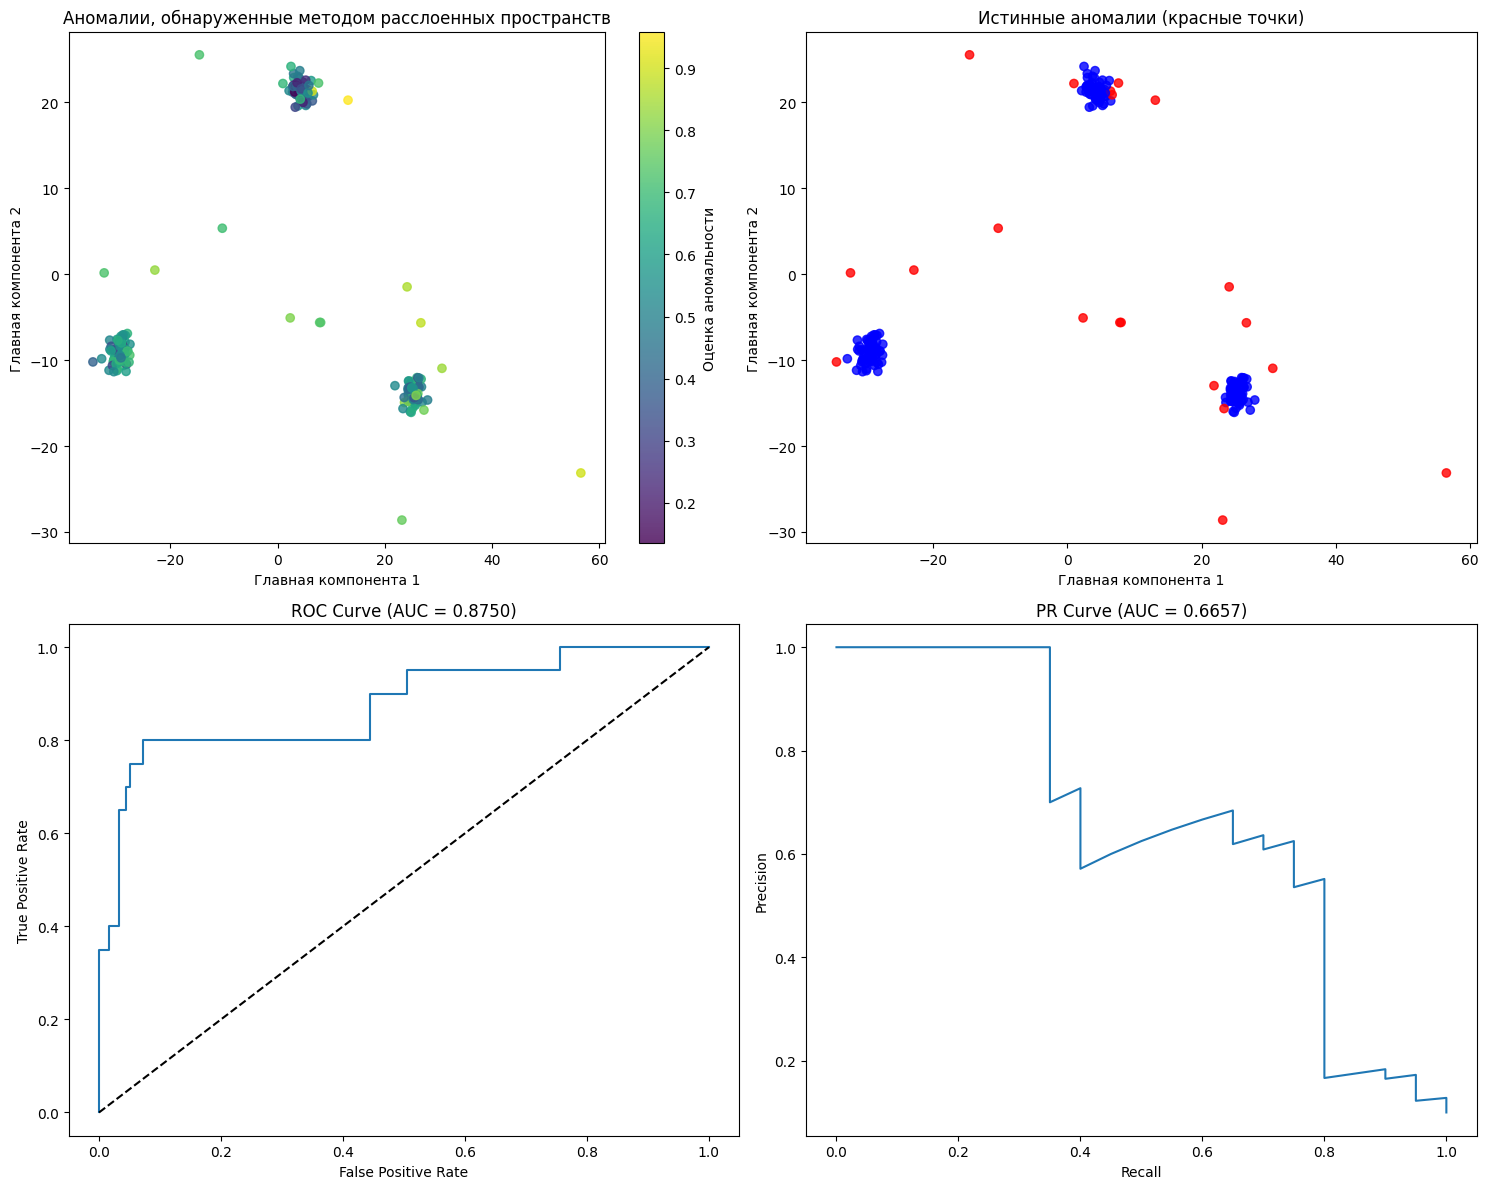

In [19]:
def generate_synthetic_data(n_samples=100, n_features=10, n_clusters=3, cluster_std=1.0, random_state=42):
    """
    Генерирует синтетические данные с заданным количеством кластеров.
    
    Args:
        n_samples: Количество образцов
        n_features: Количество признаков
        n_clusters: Количество кластеров
        cluster_std: Стандартное отклонение для кластеров
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Сгенерированные данные формы (n_samples, n_features)
    """
    np.random.seed(random_state)
    
    cluster_centers = np.random.randn(n_clusters, n_features) * 10
    
    X = np.zeros((n_samples, n_features))
    samples_per_cluster = n_samples // n_clusters
    
    for i in range(n_clusters):
        start_idx = i * samples_per_cluster
        end_idx = (i + 1) * samples_per_cluster if i < n_clusters - 1 else n_samples
        
        n_cluster_samples = end_idx - start_idx
        X[start_idx:end_idx] = cluster_centers[i] + np.random.randn(n_cluster_samples, n_features) * cluster_std
    
    np.random.shuffle(X)
    return X

def create_synthetic_anomalies(data, anomaly_ratio=0.2, anomaly_scale=5.0, random_state=42):
    """
    Создает синтетические аномалии путем добавления шума или изменения структуры данных.
    
    Args:
        data: Исходные данные
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Данные с аномалиями и индексы аномальных образцов
    """
    np.random.seed(random_state)
    data_with_anomalies = data.copy()
    n_samples = data.shape[0]
    n_features = data.shape[1]
    
    n_anomalies = int(n_samples * anomaly_ratio)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    
    for idx in anomaly_indices:
        anomaly_type = np.random.choice(['noise', 'shift', 'scale', 'structured'])
        
        if anomaly_type == 'noise':
            data_with_anomalies[idx] += np.random.randn(n_features) * anomaly_scale
            
        elif anomaly_type == 'shift':
            data_with_anomalies[idx] += anomaly_scale * np.random.randn()
            
        elif anomaly_type == 'scale':
            scale_factor = np.random.choice([anomaly_scale, 1/anomaly_scale])
            data_with_anomalies[idx] *= scale_factor
            
        else:  # 'structured'
            t = np.linspace(0, 10, n_features)
            freq = np.random.uniform(1, 5)
            amplitude = np.random.uniform(1, anomaly_scale)
            data_with_anomalies[idx] += amplitude * np.sin(2 * np.pi * freq * t)
    
    return data_with_anomalies, anomaly_indices

def compute_tangent_space(data, n_neighbors=15, n_components=None):
    """
    Вычисляет базис касательного пространства для каждой точки данных.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для построения локального базиса
        n_components: Размерность касательного пространства, по умолчанию половина размерности данных
        
    Returns:
        Список базисов касательных пространств для каждой точки и индексы соседей
    """
    n_samples, n_features = data.shape
    
    if n_components is None:
        n_components = min(n_features // 2, n_neighbors - 1)
        n_components = max(n_components, 1)
    
    # Находим ближайших соседей для каждой точки
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    # Исключаем саму точку из списка соседей
    indices = indices[:, 1:]
    
    tangent_bases = []
    
    for i in range(n_samples):
        # Центрируем соседей относительно текущей точки
        neighborhood = data[indices[i]]
        center = data[i]
        centered_neighbors = neighborhood - center
        
        # SVD для получения ортогонального базиса касательного пространства
        U, S, Vt = np.linalg.svd(centered_neighbors, full_matrices=False)
        tangent_basis = Vt[:n_components].T  # Первые n_components столбцов - базис касательного пространства
        
        tangent_bases.append(tangent_basis)
    
    return tangent_bases, indices

def compute_connection_form(data, tangent_bases, neighbor_indices):
    """
    Вычисляет форму связности между соседними касательными пространствами.
    
    Args:
        data: Данные формы (n_samples, n_features)
        tangent_bases: Список базисов касательных пространств
        neighbor_indices: Индексы соседей для каждой точки
        
    Returns:
        Список матриц связности для каждой пары соседних точек
    """
    n_samples = data.shape[0]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    connection_forms = {}
    
    for i in range(n_samples):
        basis_i = tangent_bases[i]
        
        for j_idx, j in enumerate(neighbor_indices[i]):
            basis_j = tangent_bases[j]
            
            # Вычисляем матрицу связности между касательными пространствами в точках i и j
            # A_{ij} = basis_i^T * basis_j
            connection_matrix = np.dot(basis_i.T, basis_j)
            connection_forms[(i, j)] = connection_matrix
    
    return connection_forms

def compute_curvature_from_connection(data, tangent_bases, neighbor_indices, connection_forms):
    """
    Вычисляет тензор кривизны из формы связности.
    
    Args:
        data: Данные формы (n_samples, n_features)
        tangent_bases: Список базисов касательных пространств
        neighbor_indices: Индексы соседей для каждой точки
        connection_forms: Словарь матриц связности
        
    Returns:
        Оценки кривизны для каждой точки
    """
    n_samples = data.shape[0]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    curvature_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        local_curvature = 0.0
        count = 0
        
        for j_idx, j in enumerate(neighbor_indices[i]):
            for k_idx, k in enumerate(neighbor_indices[i]):
                if j_idx >= k_idx:
                    continue 
                
                A_ij = connection_forms.get((i, j), None)
                A_ik = connection_forms.get((i, k), None)
                A_jk = connection_forms.get((j, k), None)
                A_kj = connection_forms.get((k, j), None)
                
                if A_ij is None or A_ik is None or (A_jk is None and A_kj is None):
                    continue
                
                if A_jk is None and A_kj is not None:
                    A_jk = A_kj.T
                elif A_jk is None and A_kj is None:
                    continue
                
                parallel_transport = np.dot(np.dot(A_ij, A_jk), A_ik.T)
                curvature = np.linalg.norm(parallel_transport - np.eye(n_components), 'fro')
                
                local_curvature += curvature
                count += 1
        
        if count > 0:
            curvature_scores[i] = local_curvature / count
    
    if np.max(curvature_scores) > np.min(curvature_scores):
        curvature_scores = (curvature_scores - np.min(curvature_scores)) / (np.max(curvature_scores) - np.min(curvature_scores))
    
    return curvature_scores

def compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms, n_paths=10, path_length=3):
    """
    Вычисляет голономию для каждой точки, оценивая параллельный перенос по замкнутым путям.
    
    Args:
        data: Данные формы (n_samples, n_features)
        tangent_bases: Список базисов касательных пространств
        neighbor_indices: Индексы соседей для каждой точки
        connection_forms: Словарь матриц связности
        n_paths: Количество случайных путей для каждой точки
        path_length: Длина каждого пути
        
    Returns:
        Голономия для каждой точки
    """
    n_samples = data.shape[0]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    holonomy_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        local_holonomy = 0.0
        valid_paths = 0
        
        for _ in range(n_paths):
            path = [i]
            current = i
            
            for step in range(path_length):
                next_idx = np.random.randint(0, n_neighbors)
                next_point = neighbor_indices[current][next_idx]
                
                path.append(next_point)
                current = next_point
            
            path.append(i)
            
            transport = np.eye(n_components)
            valid_path = True
            
            for p in range(len(path) - 1):
                start = path[p]
                end = path[p + 1]
                
                connection = connection_forms.get((start, end), None)
                if connection is None:
                    connection = connection_forms.get((end, start), None)
                    if connection is None:
                        valid_path = False
                        break
                    connection = connection.T
                
                transport = np.dot(transport, connection)
            
            if valid_path:
                holonomy = np.linalg.norm(transport - np.eye(n_components), 'fro')
                local_holonomy += holonomy
                valid_paths += 1
        
        if valid_paths > 0:
            holonomy_scores[i] = local_holonomy / valid_paths
    
    if np.max(holonomy_scores) > np.min(holonomy_scores):
        holonomy_scores = (holonomy_scores - np.min(holonomy_scores)) / (np.max(holonomy_scores) - np.min(holonomy_scores))
    
    return holonomy_scores

def compute_section_irregularity(data, tangent_bases, neighbor_indices):
    """
    Вычисляет нерегулярность сечений для оценки аномалий.
    
    Args:
        data: Данные формы (n_samples, n_features)
        tangent_bases: Список базисов касательных пространств
        neighbor_indices: Индексы соседей для каждой точки
        
    Returns:
        Оценка нерегулярности сечений для каждой точки
    """
    n_samples = data.shape[0]
    n_features = data.shape[1]
    n_neighbors = neighbor_indices.shape[1]
    n_components = tangent_bases[0].shape[1]
    
    section_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        point = data[i]
        neighbors = data[neighbor_indices[i]]
        tangent_space = tangent_bases[i]
        
        proj_neighbors = np.dot(neighbors - point, tangent_space)
        reconstructed = point + np.dot(proj_neighbors, tangent_space.T)
        
        errors = np.linalg.norm(neighbors - reconstructed, axis=1)
        section_scores[i] = np.mean(errors)
    
    if np.max(section_scores) > np.min(section_scores):
        section_scores = (section_scores - np.min(section_scores)) / (np.max(section_scores) - np.min(section_scores))
    
    return section_scores

def detect_anomalies_with_fiber_bundles(data, n_neighbors=15, curvature_weight=0.4, 
                                        holonomy_weight=0.4, section_weight=0.2):
    """
    Обнаруживает аномалии, используя метод расслоенных пространств.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для анализа
        curvature_weight: Вес оценки кривизны
        holonomy_weight: Вес оценки голономии
        section_weight: Вес оценки нерегулярности сечений
        
    Returns:
        Оценки аномальности для каждой точки
    """
    tangent_bases, neighbor_indices = compute_tangent_space(data, n_neighbors)
    connection_forms = compute_connection_form(data, tangent_bases, neighbor_indices)
    curvature_scores = compute_curvature_from_connection(data, tangent_bases, neighbor_indices, connection_forms)
    holonomy_scores = compute_holonomy(data, tangent_bases, neighbor_indices, connection_forms)
    section_scores = compute_section_irregularity(data, tangent_bases, neighbor_indices)
    
    # Комбинируем оценки с учетом весов
    combined_scores = (curvature_weight * curvature_scores + 
                       holonomy_weight * holonomy_scores + 
                       section_weight * section_scores)
    
    return combined_scores

def evaluate_fiber_bundle_anomaly_detection(n_samples=200, n_features=10, anomaly_ratio=0.1, 
                                           anomaly_scale=5.0, n_neighbors=15, random_state=42):
    """
    Оценивает эффективность обнаружения аномалий с использованием метода расслоенных пространств.
    
    Args:
        n_samples: Количество образцов
        n_features: Количество признаков
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        n_neighbors: Количество соседей для анализа локальной геометрии
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Метрики ROC AUC и PR AUC, а также оценки аномальности и истинные метки
    """
    synthetic_data = generate_synthetic_data(n_samples=n_samples, n_features=n_features, 
                                            n_clusters=3, random_state=random_state)
    
    data_with_anomalies, anomaly_indices = create_synthetic_anomalies(
        synthetic_data, anomaly_ratio=anomaly_ratio, anomaly_scale=anomaly_scale, 
        random_state=random_state
    )
    
    # Метки: 1 для аномалий, 0 для нормальных
    true_labels = np.zeros(n_samples)
    true_labels[anomaly_indices] = 1
    
    anomaly_scores = detect_anomalies_with_fiber_bundles(
        data_with_anomalies, n_neighbors=n_neighbors,
        curvature_weight=0.4, holonomy_weight=0.4, section_weight=0.2
    )
    
    roc_auc = roc_auc_score(true_labels, anomaly_scores)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    pr_auc = auc(recall, precision)
    
    print(f"\nРезультаты обнаружения аномалий с помощью метода расслоенных пространств:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    
    visualize_fiber_bundle_results(data_with_anomalies, anomaly_scores, true_labels, roc_auc, pr_auc)
    
    return roc_auc, pr_auc, anomaly_scores, true_labels

def visualize_fiber_bundle_results(data, anomaly_scores, true_labels, roc_auc, pr_auc):
    """
    Визуализирует результаты обнаружения аномалий методом расслоенных пространств.
    
    Args:
        data: Исходные данные
        anomaly_scores: Оценки аномальности
        true_labels: Истинные метки (1 для аномалий, 0 для нормальных)
        roc_auc: Значение ROC AUC
        pr_auc: Значение PR AUC
    """

    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    
    plt.figure(figsize=(15, 12))
    
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=anomaly_scores, 
                         cmap='viridis', alpha=0.8)
    plt.colorbar(scatter, label='Оценка аномальности')
    plt.xlabel('Главная компонента 1')
    plt.ylabel('Главная компонента 2')
    plt.title('Аномалии, обнаруженные методом расслоенных пространств')
    
    plt.subplot(2, 2, 2)
    colors = ['blue' if label == 0 else 'red' for label in true_labels]
    plt.scatter(data_2d[:, 0], data_2d[:, 1], c=colors, alpha=0.8)
    plt.xlabel('Главная компонента 1')
    plt.ylabel('Главная компонента 2')
    plt.title('Истинные аномалии (красные точки)')
    
    # ROC кривая
    plt.subplot(2, 2, 3)
    fpr, tpr, _ = roc_curve(true_labels, anomaly_scores)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
    
    # PR кривая
    plt.subplot(2, 2, 4)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve (AUC = {pr_auc:.4f})')
    
    plt.tight_layout()
    plt.savefig('fiber_bundle_anomaly_detection.png')
    plt.show()

if __name__ == "__main__":
    params = {
        'n_samples': 200,         # Количество образцов
        'n_features': 12,         # Размерность данных
        'anomaly_ratio': 0.1,     # Доля аномалий
        'anomaly_scale': 10.0,    # Масштаб аномалий
        'n_neighbors': 25,        # Количество соседей для анализа локальной геометрии
        'random_state': 42        # Случайное состояние для воспроизводимости
    }
    
    roc_auc, pr_auc, scores, true_labels = evaluate_fiber_bundle_anomaly_detection(**params)
